<h2>Why This Project?</h2>
<p></p>Imagine India as a big family. Just like a family keeps track of how much money it earns, spends, and saves, a country keeps track of its GDP (Gross Domestic Product). GDP is like the “report card” of how much the country is producing and earning.

Imagine India as a big family. Just like a family keeps track of how much money it earns, spends, and saves, a country keeps track of its GDP (Gross Domestic Product). GDP is like the “report card” of how much the country is producing and earning.</p>


<h2>Why It’s Important</h2>
<p><b>GDP shows progress</b>: If GDP grows, it means the country is making more things, providing more services,<br> and people may be earning more.

<b>Population shows size</b>: Knowing how many people live in India helps us understand how resources are shared.

<b>Life expectancy shows health</b>: If people live longer, it means healthcare, food, and living conditions are improving.</p>

<h2>What Can Be Found in This Project</h2>
<b>GDP Growth Trends (1960–2020)</b>: How India’s economy expanded over six decades.

<b>Population Growth</b>: How India’s population rose past 1 billion and what that means for resources.

<b>Life Expectancy</b>: How improvements in healthcare and living conditions helped people live longer.

<b>Combined View</b>: A clear picture of how economic growth, population, and health are connected.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("indianEco.csv")
df.head()

,Year,Country Name,GDP (current US$),GDP per capita (current US$),GDP growth (annual %),Imports of goods and services (% of GDP),Exports of goods and services (% of GDP),"Total reserves (includes gold, current US$)","Inflation, consumer prices (annual %)","Population, total",Population growth (annual %),"Life expectancy at birth, total (years)"
0,1960,India,3.702988e+10,82,0.00,6.83,4.46,6.745366e+08,1.78,445954579,2.31,41.13
1,1961,India,3.923244e+10,85,3.72,5.96,4.30,6.663571e+08,1.70,456351876,2.33,41.74
2,1962,India,4.216148e+10,90,2.93,6.03,4.17,5.127918e+08,3.63,467024193,2.34,42.34
3,1963,India,4.842192e+10,101,5.99,5.91,4.28,6.078625e+08,2.95,477933619,2.34,42.94
4,1964,India,5.648029e+10,116,7.45,5.69,3.73,4.991451e+08,13.36,489059309,2.33,43.57


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Year                                           61 non-null     int64  
 1   Country Name                                   61 non-null     object 
 2   GDP (current US$)                              61 non-null     float64
 3    GDP per capita (current US$)                  61 non-null     int64  
 4   GDP growth (annual %)                          61 non-null     float64
 5   Imports of goods and services (% of GDP)       61 non-null     float64
 6   Exports of goods and services (% of GDP)       61 non-null     float64
 7    Total reserves (includes gold, current US$)   61 non-null     float64
 8   Inflation, consumer prices (annual %)          61 non-null     float64
 9   Population, total                              61 non-nu

In [4]:
#we use regex model to remove '()' this cloumns in datasets one by one get time consume
# remove whitespace in datasets
df.columns =df.columns.str.strip()
df.columns=[re.sub(r'\s*\(.*?\)','',cols).strip() for cols in df.columns]
df.columns=df.columns.str.replace(',','').str.strip()


In [5]:
# now we rename columns in table short and simple
df.rename(columns={
    'Country Name':'Country',
    'GDP':'GDP_USA$',
    'GDP per capita':'GDP_pc',
    'GDP growth': 'GDP_gt',
    'Imports of goods and services':'Import_gs',
    'Exports of goods and services':'Exports_gs',
    'Inflation consumer prices':'Inflation_consumer',
    'Population total': 'Population',
    'Population growth': 'Pop_Growth_Pct',
    'Life expectancy at birth total': 'Life_Expectancy'
},inplace=True)

In [6]:
df.head()

,Year,Country,GDP_USA$,GDP_pc,GDP_gt,Import_gs,Exports_gs,Total reserves,Inflation_consumer,Population,Pop_Growth_Pct,Life_Expectancy
0,1960,India,3.702988e+10,82,0.00,6.83,4.46,6.745366e+08,1.78,445954579,2.31,41.13
1,1961,India,3.923244e+10,85,3.72,5.96,4.30,6.663571e+08,1.70,456351876,2.33,41.74
2,1962,India,4.216148e+10,90,2.93,6.03,4.17,5.127918e+08,3.63,467024193,2.34,42.34
3,1963,India,4.842192e+10,101,5.99,5.91,4.28,6.078625e+08,2.95,477933619,2.34,42.94
4,1964,India,5.648029e+10,116,7.45,5.69,3.73,4.991451e+08,13.36,489059309,2.33,43.57


In [7]:
df.duplicated().any()

np.False_

In [8]:
df.isnull().sum()

Year                  0
Country               0
GDP_USA$              0
GDP_pc                0
GDP_gt                0
Import_gs             0
Exports_gs            0
Total reserves        0
Inflation_consumer    0
Population            0
Pop_Growth_Pct        0
Life_Expectancy       0
dtype: int64

In [9]:
df.describe()

,Year,GDP_USA$,GDP_pc,GDP_gt,Import_gs,Exports_gs,Total reserves,Inflation_consumer,Population,Pop_Growth_Pct,Life_Expectancy
count,61.000000,6.100000e+01,61.000000,61.000000,61.000000,61.000000,6.100000e+01,61.000000,6.100000e+01,61.000000,61.000000
mean,1990.000000,6.584725e+11,575.557377,4.938197,12.746393,10.885574,9.802227e+10,7.413279,8.913946e+08,1.927705,57.146230
std,17.752934,8.129606e+11,584.079062,3.344891,8.155110,7.060458,1.497102e+11,4.940153,2.974496e+08,0.419024,8.459559
min,1960.000000,3.702988e+10,82.000000,-7.250000,3.710000,3.310000,4.991451e+08,-7.630000,4.459546e+08,0.960000,41.130000
25%,1975.000000,9.952590e+10,161.000000,3.720000,6.590000,5.200000,2.324650e+09,4.010000,6.235242e+08,1.620000,50.630000
50%,1990.000000,2.882084e+11,340.000000,5.530000,8.570000,7.050000,1.151174e+10,6.670000,8.704522e+08,2.150000,57.660000
75%,2005.000000,8.203816e+11,715.000000,7.450000,19.640000,18.690000,1.378248e+11,10.020000,1.154639e+09,2.260000,64.310000
max,2020.000000,2.831552e+12,2101.000000,9.630000,31.260000,25.430000,5.902274e+11,28.600000,1.396387e+09,2.340000,69.730000


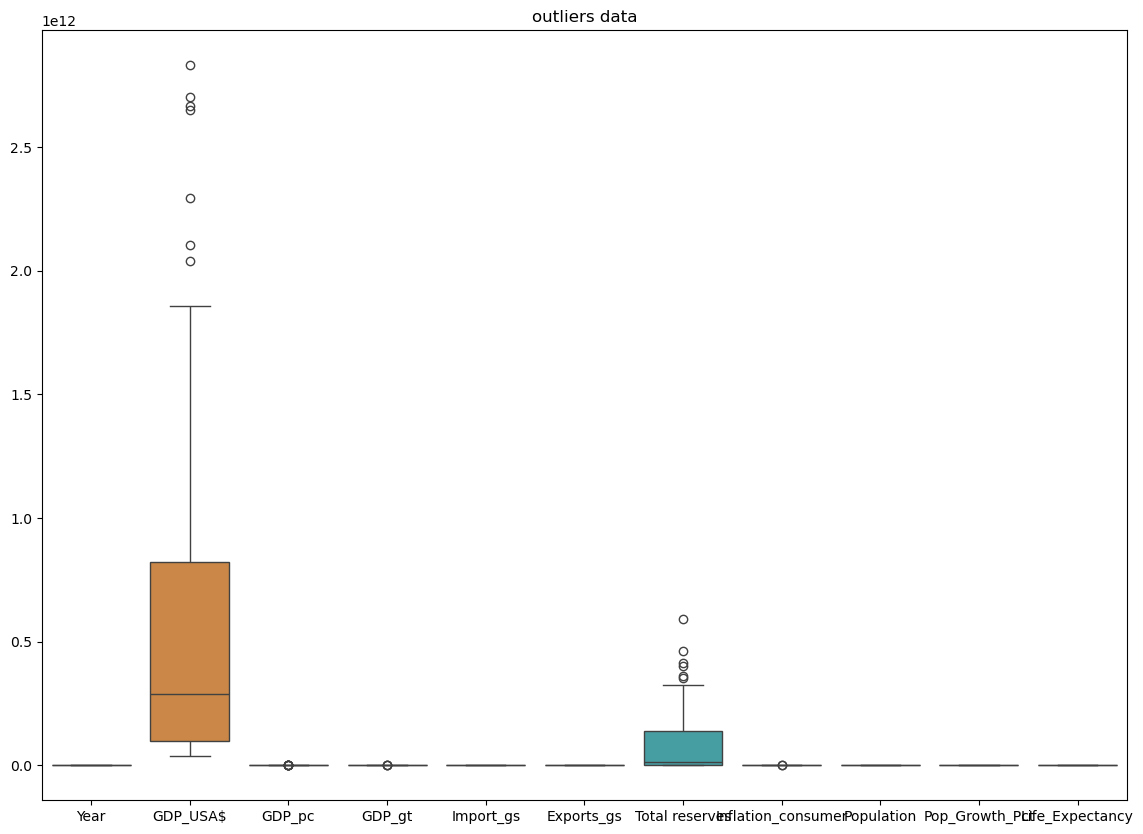

In [10]:
plt.figure(figsize=(14,10))
sns.boxplot(data=df)
plt.title("outliers data")
plt.show()

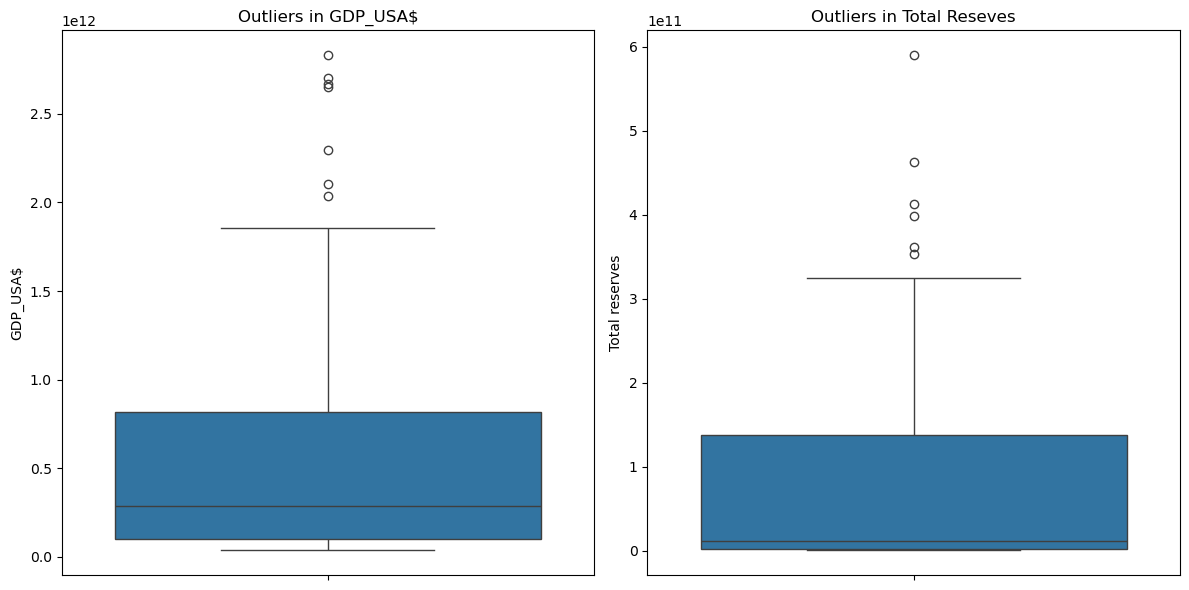

In [11]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.boxplot(y=df['GDP_USA$'])
plt.title('Outliers in GDP_USA$')

plt.subplot(1,2,2)
sns.boxplot(y=df['Total reserves'])
plt.title('Outliers in Total Reseves')
plt.tight_layout()
plt.show()

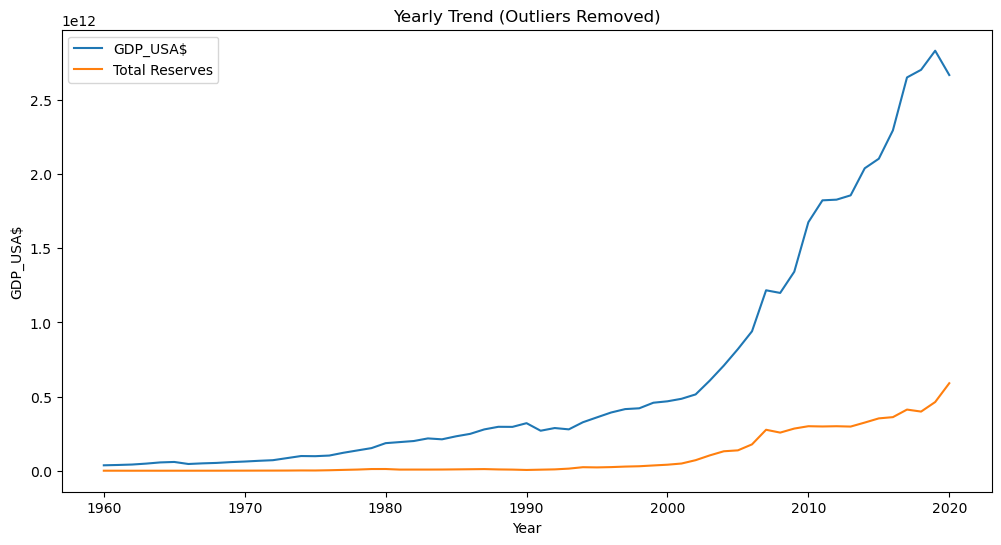

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Year', y='GDP_USA$', label='GDP_USA$')
sns.lineplot(data=df, x='Year', y='Total reserves', label='Total Reserves')
plt.title('Yearly Trend (Outliers Removed)')
plt.legend()
plt.show()


In [13]:
def remove_outliers_all(df): 
    df_clean = df.copy()
    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR 
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)] 
        return df_clean

In [14]:
df_clean = remove_outliers_all(df) 
print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))

Original rows: 61
Rows after removing outliers: 61


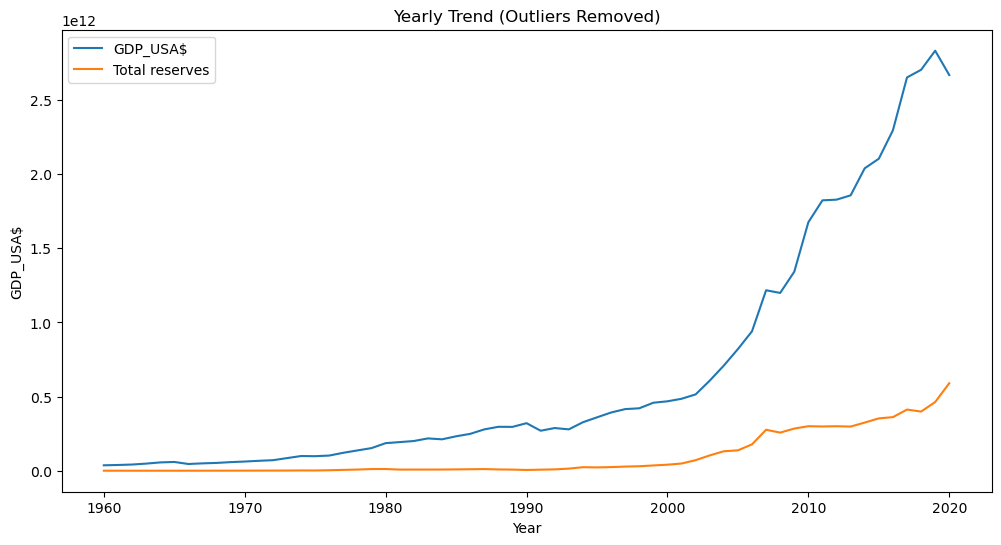

In [15]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_clean, x='Year', y='GDP_USA$', label='GDP_USA$')
sns.lineplot(data=df_clean, x='Year', y='Total reserves', label='Total reserves')
plt.title('Yearly Trend (Outliers Removed)')
plt.legend()
plt.show()

In [16]:
df_clean.head()

,Year,Country,GDP_USA$,GDP_pc,GDP_gt,Import_gs,Exports_gs,Total reserves,Inflation_consumer,Population,Pop_Growth_Pct,Life_Expectancy
0,1960,India,3.702988e+10,82,0.00,6.83,4.46,6.745366e+08,1.78,445954579,2.31,41.13
1,1961,India,3.923244e+10,85,3.72,5.96,4.30,6.663571e+08,1.70,456351876,2.33,41.74
2,1962,India,4.216148e+10,90,2.93,6.03,4.17,5.127918e+08,3.63,467024193,2.34,42.34
3,1963,India,4.842192e+10,101,5.99,5.91,4.28,6.078625e+08,2.95,477933619,2.34,42.94
4,1964,India,5.648029e+10,116,7.45,5.69,3.73,4.991451e+08,13.36,489059309,2.33,43.57


In [19]:
df1=df_clean.copy()

In [20]:
df1.sort_values('Year',inplace=True)
df1.reset_index(drop=True,inplace=True)

<h2>India’s GDP Growth Analysis (1960–2020) </h2>

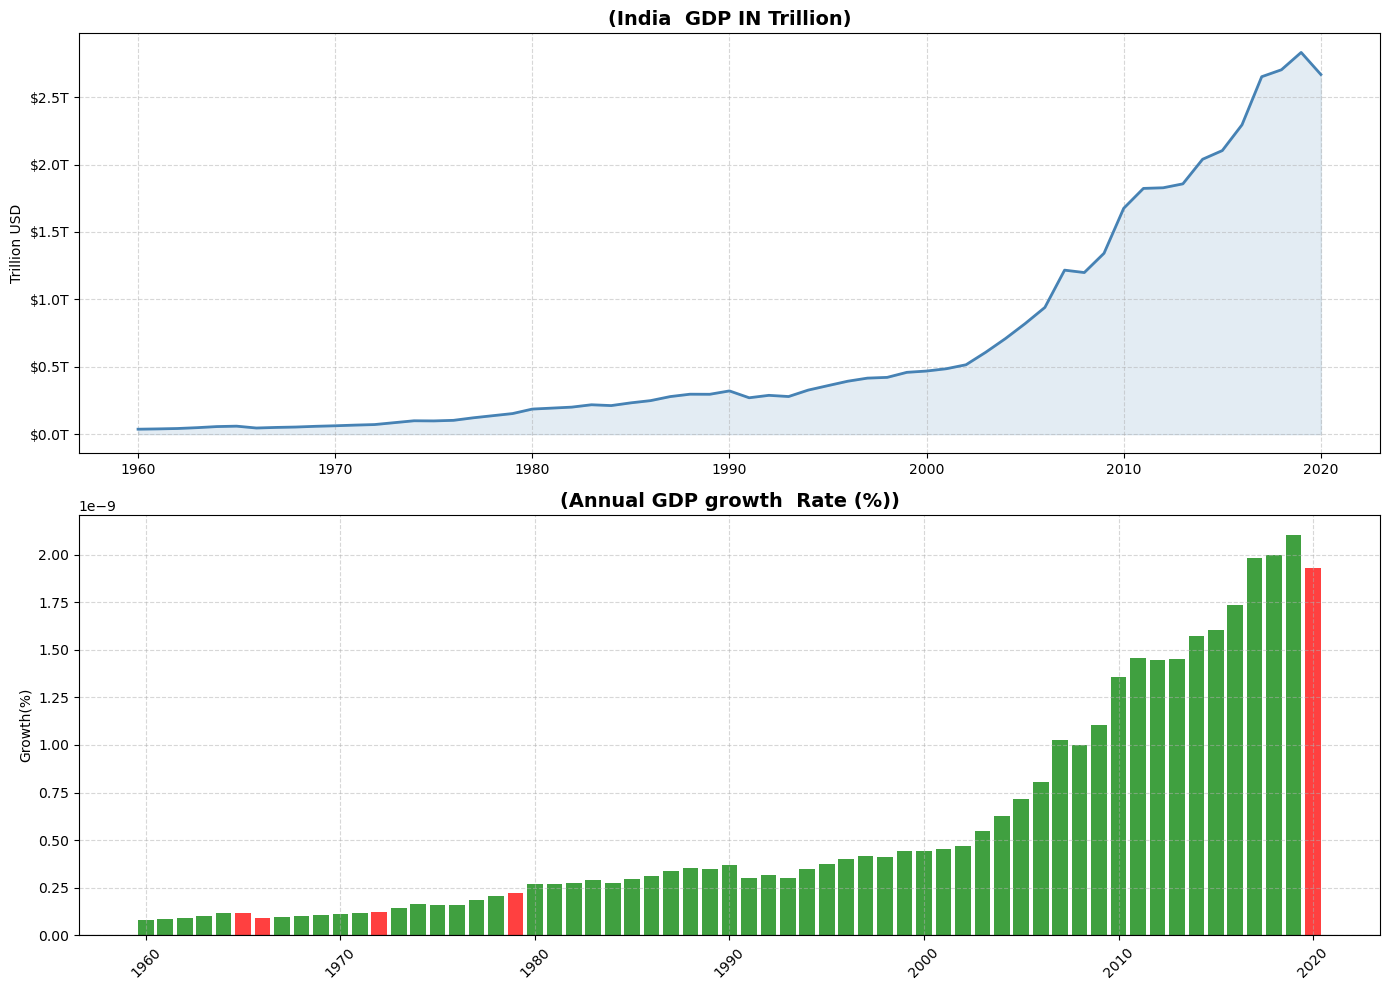

In [28]:
fig,axes=plt.subplots(2,1, figsize=(14,10))
axes[0].plot(df1['Year'],df1['GDP_USA$']/1e12,color='steelblue',linewidth=2),
axes[0].fill_between(df1['Year'],df['GDP_USA$']/1e12,alpha=0.15,color='steelblue'),
axes[0].set_title('(India  GDP IN Trillion)',fontsize=14,fontweight='bold')
axes[0].set_ylabel('Trillion USD')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fT'))
axes[0].grid(True,linestyle='--',alpha=0.5)

color=['green' if x >=0 else 'red' for x in df['GDP_gt']]
axes[1].bar(df1['Year'],df1['GDP_pc']/1e12,color=color,alpha=0.75),
axes[1].axhline(0, color='black',linewidth=0.8)
axes[1].set_title('(Annual GDP growth  Rate (%))',fontsize=14,fontweight='bold')
axes[1].set_ylabel('Growth(%)')
axes[1].grid(True,linestyle='--',alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h2>Demographic Indicators: Life Expectancy & Population, 1960–2020</h2>


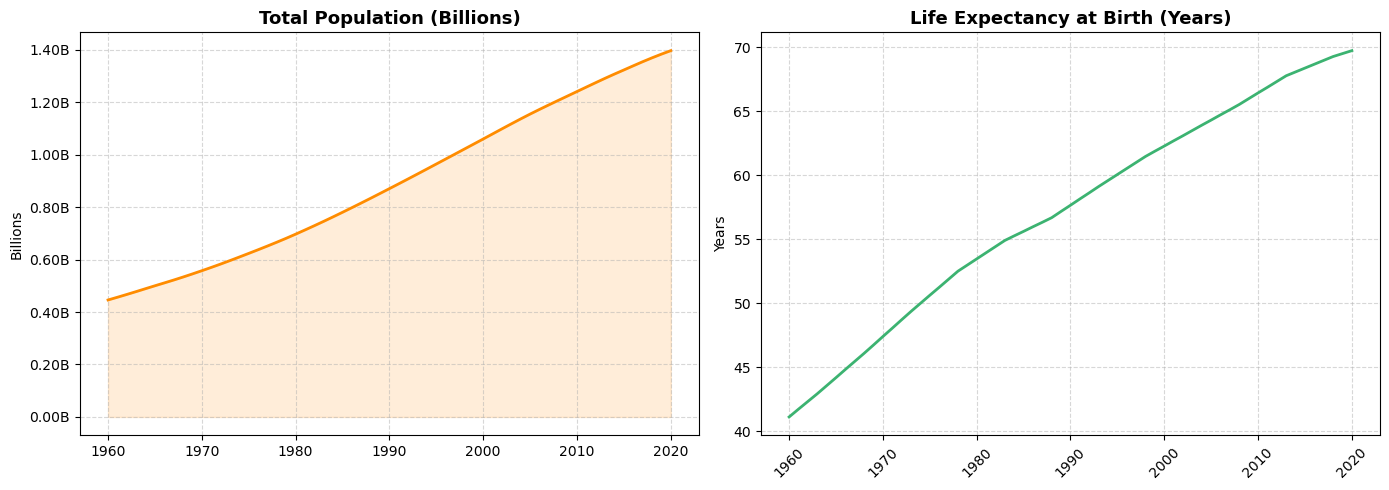

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df1['Year'], df1['Population'] / 1e9, color='darkorange', linewidth=2)
axes[0].fill_between(df['Year'], df1['Population'] / 1e9, alpha=0.15, color='darkorange')
axes[0].set_title('Total Population (Billions)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Billions')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fB'))
axes[0].grid(True, linestyle='--', alpha=0.5)


axes[1].plot(df1['Year'], df1['Life_Expectancy'], color='mediumseagreen', linewidth=2)
axes[1].set_title('Life Expectancy at Birth (Years)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Years')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

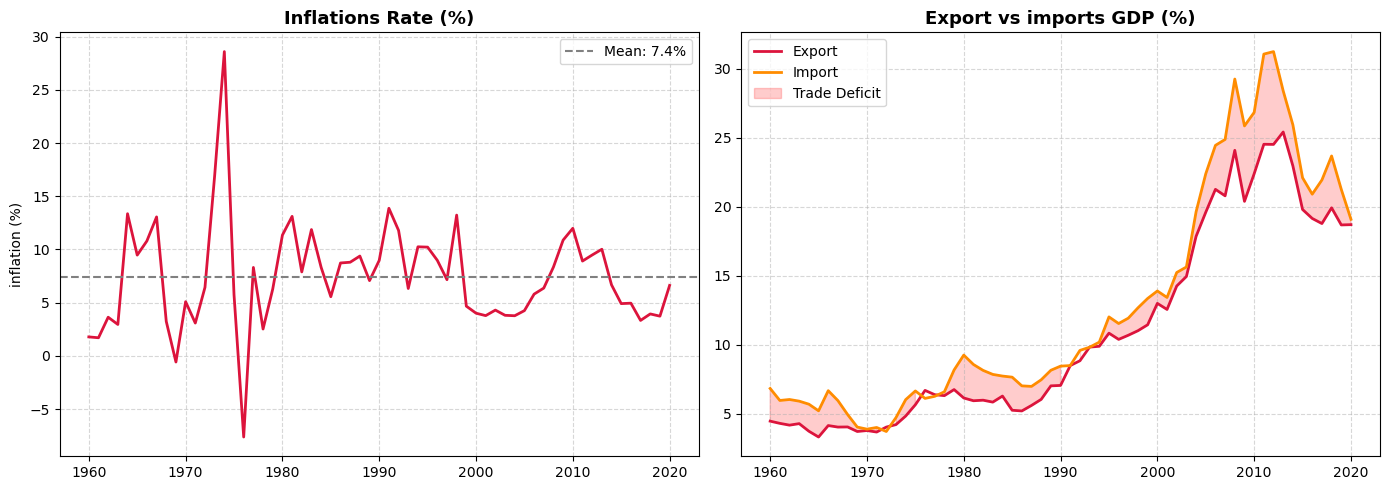

In [50]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(df1['Year'], df1['Inflation_consumer'], color='crimson', linewidth=2)
axes[0].axhline(df1['Inflation_consumer'].mean(), color='grey', linestyle='--', label=f"Mean: {df1['Inflation_consumer'].mean():.1f}%")
axes[0].set_title('Inflations Rate (%)', fontsize=13,fontweight='bold')
axes[0].set_ylabel('inflation (%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(df1['Year'],df1['Exports_gs'],label='Export',color='crimson',linewidth=2),
axes[1].plot(df1['Year'],df1['Import_gs'],label='Import',color='darkorange',linewidth=2),
axes[1].fill_between(df['Year'], df['Exports_gs'], df['Import_gs'],
                     where=df['Import_gs'] > df['Exports_gs'],
                     alpha=0.2, color='red', label='Trade Deficit')
axes[1].set_title('Export vs imports GDP (%)', fontsize=13,fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

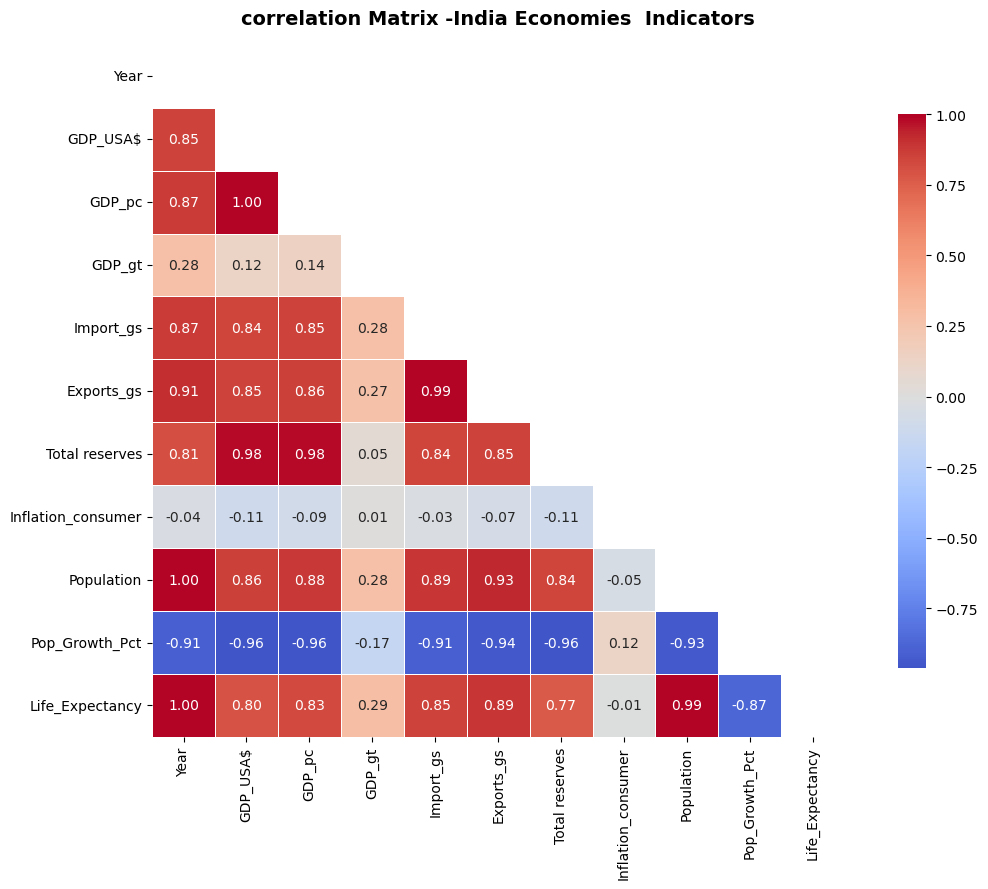

In [57]:
numeric_df=df.drop(columns=['Country'])
corr=numeric_df.corr().round(2)
plt.figure(figsize=(12,9))
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, mask=mask,annot=True,fmt='.2f',cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('correlation Matrix -India Economies  Indicators',fontsize=14,fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [64]:
df1['Decade'] = (df1['Year'] // 10 * 10).astype(str) + 's'

decade_summary = df1.groupby('Decade').agg(
    Avg_GDP_Growth=('GDP_gt', 'mean'),
    Avg_Inflation=('Inflation_consumer', 'mean'),
    Avg_Life_Expectancy=('Life_Expectancy', 'mean'),
    Avg_Imports_Pct=('Import_gs', 'mean'),
    Avg_Exports_Pct=('Exports_gs', 'mean'),
    Avg_Pop_Growth=('Pop_Growth_Pct', 'mean')
).round(2)

decade_summary

,Avg_GDP_Growth,Avg_Inflation,Avg_Life_Expectancy,Avg_Imports_Pct,Avg_Exports_Pct,Avg_Pop_Growth
Decade,,,,,,
1960s,3.51,5.94,43.91,5.72,4.02,2.27
1970s,2.93,7.54,50.28,5.61,5.23,2.25
1980s,5.69,9.21,55.38,7.88,5.93,2.26
1990s,5.77,9.55,59.81,10.81,9.85,2.02
2000s,6.28,5.53,64.11,20.47,17.88,1.64
2010s,6.66,6.79,68.12,25.35,21.62,1.23
2020s,-7.25,6.62,69.73,19.10,18.71,0.96


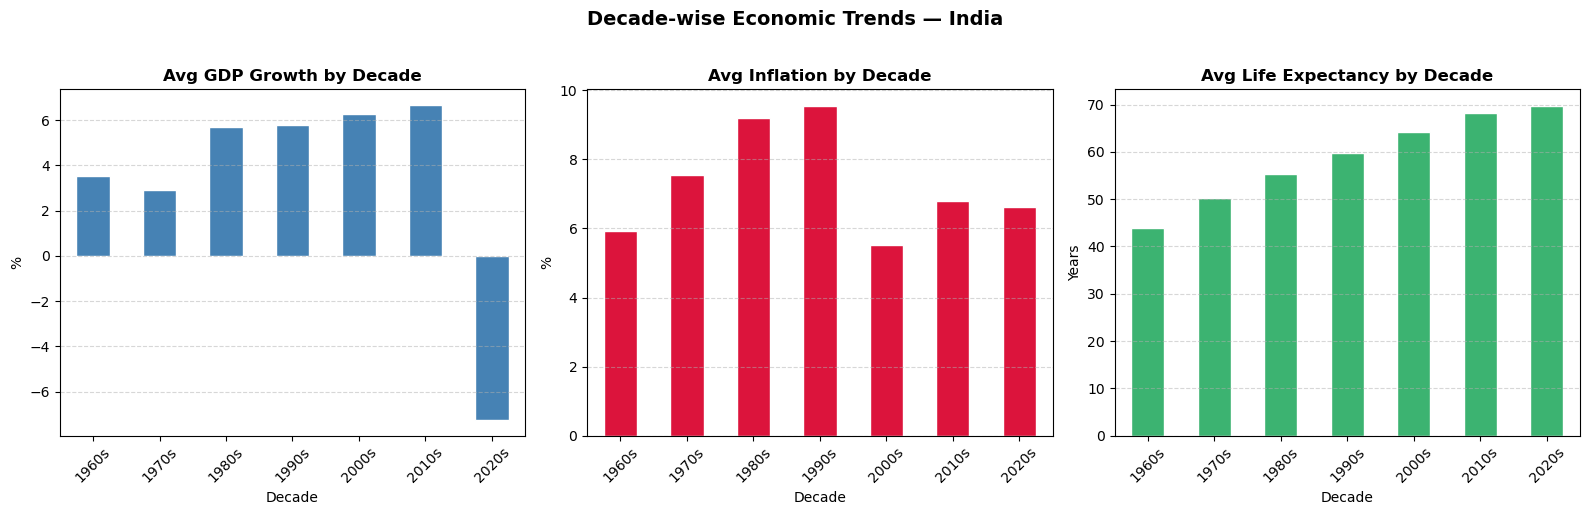

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

decade_summary['Avg_GDP_Growth'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg GDP Growth by Decade', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

decade_summary['Avg_Inflation'].plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Avg Inflation by Decade', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

decade_summary['Avg_Life_Expectancy'].plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avg Life Expectancy by Decade', fontweight='bold')
axes[2].set_ylabel('Years')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Decade-wise Economic Trends — India', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [74]:
print('=== KEY INSIGHTS ===')
print(f"Period covered       : {df1['Year'].min()} – {df1['Year'].max()}")
print(f"GDP (1960)           : ${df1.loc[df1['Year']==1960, 'GDP_USA$'].values[0]/1e9:.1f}B")
print(f"GDP (2020)           : ${df1.loc[df1['Year']==2020, 'GDP_USA$'].values[0]/1e12:.2f}T")
print(f"Highest GDP growth   : {df1['GDP_gt'].max():.2f}% in {df1.loc[df1['GDP_gt'].idxmax(), 'Year']}")
print(f"Lowest GDP growth    : {df1['GDP_gt'].min():.2f}% in {df1.loc[df1['GDP_gt'].idxmin(), 'Year']}")
print(f"Peak inflation       : {df1['Inflation_consumer'].max():.2f}% in {df1.loc[df['Inflation_consumer'].idxmax(), 'Year']}")
print(f"Life expectancy gain : {df1['Life_Expectancy'].min():.1f} → {df1['Life_Expectancy'].max():.1f} years")
print(f"Population growth    : {df1['Population'].min()/1e6:.0f}M → {df1['Population'].max()/1e9:.2f}B")
print(f"Avg trade deficit    : {(df1['Import_gs'] - df1['Exports_gs']).mean():.2f}% of GDP")

=== KEY INSIGHTS ===
Period covered       : 1960 – 2020
GDP (1960)           : $37.0B
GDP (2020)           : $2.67T
Highest GDP growth   : 9.63% in 1988
Lowest GDP growth    : -7.25% in 2020
Peak inflation       : 28.60% in 1974
Life expectancy gain : 41.1 → 69.7 years
Population growth    : 446M → 1.40B
Avg trade deficit    : 1.86% of GDP


<h2>Period covered: 1960–2020 </h2>

<p>GDP (1960): ~$37B → Matches World Bank data.

GDP (2020): ~$2.67T → (World Bank reports ~2.62–2.67T).


Highest GDP growth: 9.63% in 1988 , India’s peak growth year.

Lowest GDP growth: -7.25% in 2020 , due to COVID-19 impact.

Peak inflation: 28.60% in 1974 , India faced very high inflation during the oil crisis.

Life expectancy gain: 41.1 years (1960) 69.7 years (2020) → Correct, WHO/World Bank data confirm this.

Population growth: 446M (1960) → 1.40B (2020) , UN and World Bank data align.

Avg trade deficit: ~1.86% of GDP , India consistently ran trade deficits in this range.</p>